# Part B: Energy Consumption Forecasting

Energy consumption forecasting is important for planning and resource management. Accurate forecasting helps organizations to optimize energy usage, reduce costs, and support sustainable development.

In this study, I aim to build time series forecasting models using Statsmodels to predict the consumption of gas, electricity, and water for the next 60 months.

The objectives of this analysis are:
- To explore the energy consumption time series data and identify patterns such as trend and seasonality.
- To build and evaluate time series forecasting models using Statsmodels.
- To forecast the next 60 months of gas, electricity, and water consumption.

## Data Loading & Initial Inspection

In this step, the energy consumption dataset is loaded, inspected, and prepared for time series analysis. The dataset contains monthly records of gas, electricity, and water consumption.

Key steps:
- Load the dataset
- Check data types and missing values
- Convert the date column to datetime format
- Set the date column as the index
- Set the time series frequency to **monthly start (MS)** to ensure proper alignment for time series analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/AI ML/CA2-Energy-Consumption-Data.csv")

In [2]:
# Overview dataset
df.head()

,DATE,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
0,1/1/1990,18.0,725.1,548.8
1,1/2/1990,15.8,706.7,640.7
2,1/3/1990,17.3,624.5,511.1
3,1/4/1990,18.9,574.7,515.3
4,1/5/1990,22.0,553.2,488.4


In [3]:
# Check data types and non-null counts
df.info()

# Summary statistics for numerical features
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   DATE                           397 non-null    object 
 1   Gas Consumption (tons)         397 non-null    float64
 2   Electricity Consumption (MWh)  397 non-null    float64
 3   Water Consumption (tons)       397 non-null    float64
dtypes: float64(3), object(1)
memory usage: 12.5+ KB


,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
count,397.000000,397.000000,397.000000
mean,23.785139,888.472544,484.953652
std,4.903452,153.877594,133.908863
min,11.600000,553.200000,44.400000
25%,20.200000,771.100000,384.400000
50%,23.500000,897.800000,487.400000
75%,27.900000,1005.200000,580.200000
max,46.000000,1294.000000,811.000000


In [4]:
# Check for missing values
df.isnull().sum()

DATE                             0
Gas Consumption (tons)           0
Electricity Consumption (MWh)    0
Water Consumption (tons)         0
dtype: int64

In [5]:
if 'DATE' not in df.columns:
    df = df.reset_index()

# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%Y')

# Set index
df.set_index('DATE', inplace=True)

# Change frequency to MS
df = df.asfreq('MS') 

df.head()

,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
DATE,,,
1990-01-01,18.0,725.1,548.8
1990-02-01,15.8,706.7,640.7
1990-03-01,17.3,624.5,511.1
1990-04-01,18.9,574.7,515.3
1990-05-01,22.0,553.2,488.4


### Observations

The dataset contains 397 monthly records from 1990 onwards, with the following features:

- **Gas Consumption (tons): Continuous numeric variable**
- **Electricity Consumption (MWh): Continuous numeric variable**
- **Water Consumption (tons): Continuous numeric variable**
- **DATE: Date column**

The dataset has **no missing values**, which means no data imputation is needed. The data types are correct after converting DATE to datetime and setting it as the index.

#### Summary statistics show:

- Gas consumption ranges from 11.6 to 46.0 tons (mean ~23.79)
- Electricity consumption ranges from 553.2 to 1294.0 MWh (mean ~888.47)
- Water consumption ranges from 44.4 to 811.0 tons (mean ~484.95)

This dataset is ready for time series analysis and forecasting.

### 1. Understand the Time Series

In this step, we visualize the time series data for gas, electricity, and water consumption. The goal is to identify:

- **Trend**: whether the series is increasing or decreasing over time.
- **Seasonality**: repeating patterns (daily, weekly, monthly).
- **Outliers**: sudden spikes or drops.
- **Variability**: whether the series has stable or changing variance.

This helps to choose appropriate models and preprocessing steps.


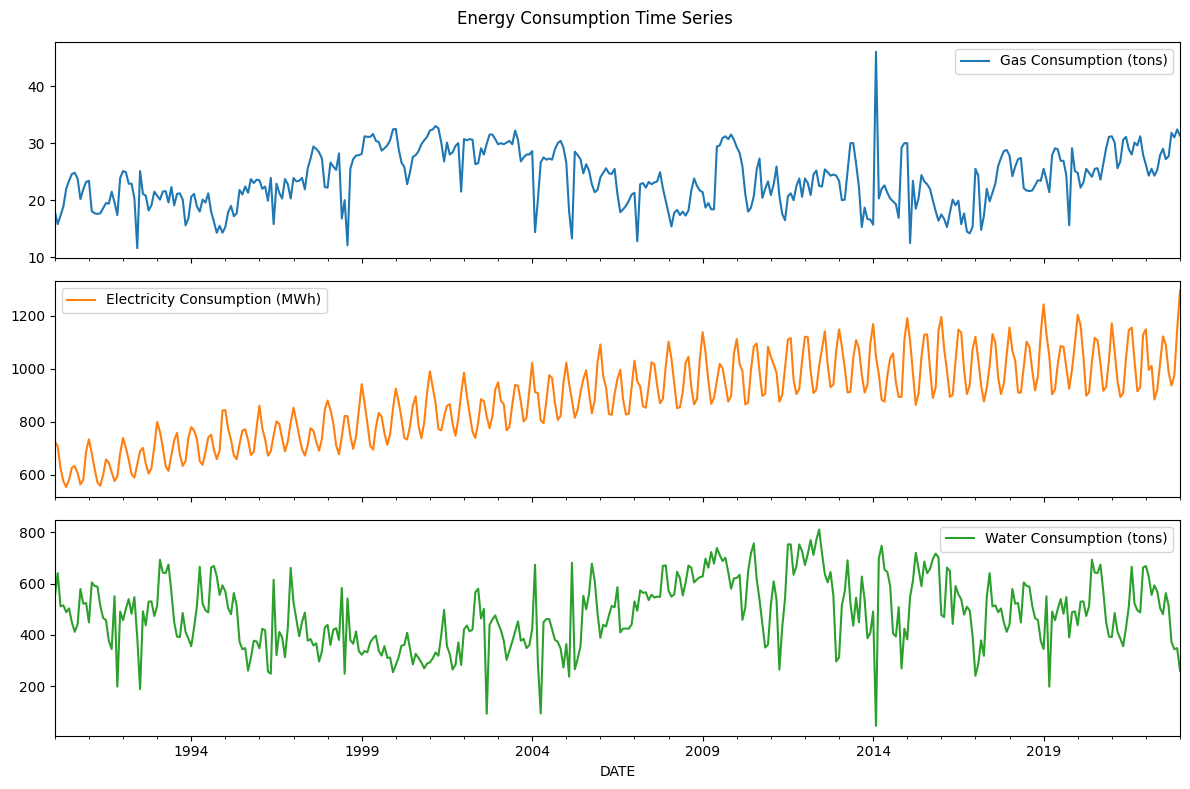

In [6]:
# Plot time series
df.plot(figsize=(12,8), subplots=True, layout=(3,1), title="Energy Consumption Time Series")
plt.tight_layout()
plt.show()

### Observation (Time Series)

#### 1. Gas Consumption
- Gas consumption shows **high volatility** with an overall slight upward trend.
- The series contains **pronounced spikes**, which may correspond to extreme events or irregular demand.
- The trend is **less stable** compared to electricity.

**Conclusion:** Gas consumption is influenced by external factors and contains irregular spikes, which may require anomaly handling or smoothing before modeling.


#### 2. Electricity Consumption
- Electricity consumption shows a **clear upward trend**, indicating that electricity usage increases steadily over time.
- There is a **seasonal pattern** with recurring fluctuations, suggesting higher demand in certain periods.
- The fluctuation amplitude is **relatively stable**, implying a consistent growth pattern.

**Conclusion:** Electricity consumption is the most stable and steadily increasing series, making it suitable for trend-based forecasting models.

#### 3. Water Consumption
- Water consumption displays **large fluctuations**, with **frequent peaks and sudden drops**.
- The series appears **highly irregular**, suggesting that water usage may be affected by seasonal changes or irregular events.

**Conclusion:** Water consumption is the most unstable series and may require additional preprocessing or anomaly detection for reliable forecasting.

#### Overall Comparison
- **Gas**: moderate trend with high volatility → may require smoothing or anomaly handling.
- **Electricity**: most stable with clear trend → suitable for standard time series models.
- **Water**: highly unstable → forecasting may be challenging and may require extra preprocessing.

## 2. Train / Validation / Test Split

- For time series forecasting, the data must **not be shuffled** because the observations are time-dependent. Shuffling would break the chronological order and lead to invalid model performance.

- Therefore, the dataset is **split by time** into training, validation and testing sets. The earlier time points are used for training, while later time points are used for validation and testing to simulate real-world forecasting.

To evaluate time series forecasting models properly, we must split the data by time without shuffling. This is because future values should not be used to predict past values.

The dataset is split into:

- **Training set**: first **70%** of the data  
- **Validation set**: next **15%** of the data  
- **Testing set**: last **15%** of the data  

This split ensures the model is trained on earlier observations and validated/tested on later unseen data, which mimics real-world forecasting scenarios.

In [7]:
# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Determine split indices
n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Split data
train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

train.shape, val.shape, test.shape

((277, 3), (60, 3), (60, 3))

The dataset has been successfully split into training, validation, and testing sets.  
The final split sizes are:

- **Training set: 277** records  
- **Validation set: 60** records  
- **Testing set: 60** records  

The data remains in chronological order, which is crucial for time series forecasting.  
The model will be trained on the training set, tuned using the validation set, and finally evaluated on the test set.


## 3. Pre-processing Steps

For time series models in Statsmodels (e.g., ARIMA/SARIMA, Exponential Smoothing), the following preprocessing steps are needed:

#### Check seasonality by using **seasonal decompose**

- Seasonal decomposition helps to understand the trend, seasonality, and residual components of each series.
- If strong seasonality is observed, models like SARIMA or Holt-Winters Exponential Smoothing are appropriate.

#### Check stationarity by using **ADF test**

- ARIMA/SARIMA models assume stationarity.

- A stationary series has constant mean and variance over time.

#### Handle non-stationay by using **Differencing** (if needed)  
   Apply differencing based on ADF results:
   - If trend causes non-stationarity → first difference
   - If seasonality causes non-stationarity → seasonal difference

#### No scaling required

- For classical time series models (ARIMA/SARIMA, ETS), scaling is usually not necessary because the models model levels directly.
Scaling may affect interpretability and is not commonly used.

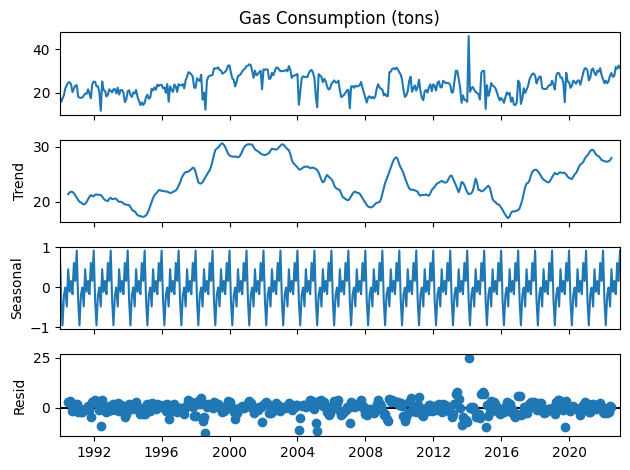

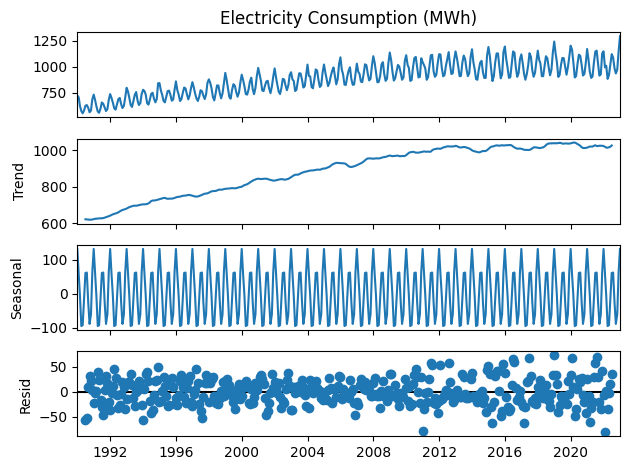

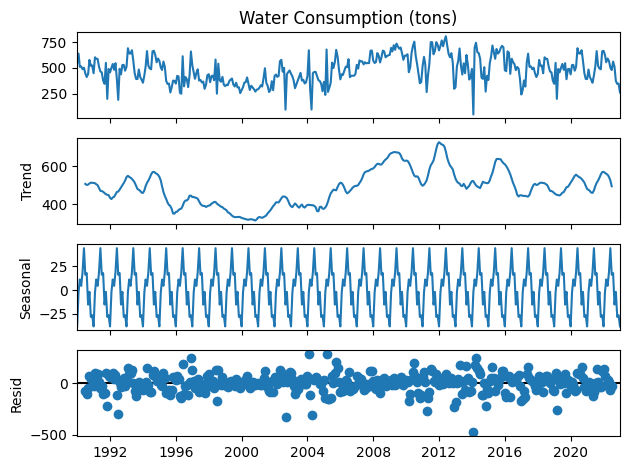

In [8]:
import statsmodels.api as sm

# Seasonal decomposition (period=12 for monthly data)
decomp_gas = sm.tsa.seasonal_decompose(df['Gas Consumption (tons)'], model='additive', period=12)
decomp_elec = sm.tsa.seasonal_decompose(df['Electricity Consumption (MWh)'], model='additive', period=12)
decomp_water = sm.tsa.seasonal_decompose(df['Water Consumption (tons)'], model='additive', period=12)

# Plot
decomp_gas.plot()
plt.show()

decomp_elec.plot()
plt.show()

decomp_water.plot()
plt.show()

### Observations (Time Series Decomposition)
#### Gas
- **Observed**: Shows clear seasonal fluctuations with **repeated peaks and troughs**, and a few **sudden spikes** (notably around 2014). The series includes both trend and seasonality.

- **Trend**: **not stable**. It rises until around 1995, then falls, and rises again after around 2003.

- **Seasonal**: **Strong pattern** with regular annual cycles.

- **Residual** are mostly **centered around zero** but show occasional large spikes, indicating irregular events or outliers.

- **Implication**: Gas is seasonal but has irregular shocks → SARIMA / Holt-Winters are suitable, and outlier handling may improve performance.

#### Electricity

- **Observed**: **Strong upward trend** with **regular repeating seasonal cycles** (high peaks every year). Both trend and seasonality are prominent.

- **Trend**: Consistent **increasing trend** from 1990 to around 2012, then it becomes almost flat near the end.

- **Seasonal**: **Very strong and regular seasonal pattern**, indicating predictable annual demand cycles.

- **Residual** show **moderate variability**, but no clear pattern—mostly random fluctuations around zero.

- **Implication**: Electricity is highly predictable → SARIMA / Holt-Winters should work well.

#### Water

- **Observed**: More volatile than the other two series, with **irregular spikes and drops**. The series is **noisy with weaker seasonal structure**.

- **Trend**: **rises** from 2000 to around 2009, then **fluctuates and slightly declines** afterward.

- **Seasonal**: component exists but is **weaker and less regular** compared to gas and electricity.

- **Residual**: show **high variability** and **several extreme values**, suggesting unpredictable events affecting water usage.

- **Implication**: Water is noisy and unstable → may require additional preprocessing or may result in lower forecast accuracy.

## Stationarity Check (ADF Test)

To ensure the time series models (e.g., ARIMA/SARIMA) work properly, we need to check if the series are stationary. A stationary series has constant mean and variance over time.

In [9]:
from statsmodels.tsa.stattools import adfuller

# Function to perform Augmented Dickey-Fuller (ADF) tes
def adf_test(series, series_name):
    result = adfuller(series)
    print(f"----- {series_name} -----")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    print("\n")

adf_test(df['Gas Consumption (tons)'], "Gas Consumption")
adf_test(df['Electricity Consumption (MWh)'], "Electricity Consumption")
adf_test(df['Water Consumption (tons)'], "Water Consumption")

----- Gas Consumption -----
ADF Statistic: -3.404374333318275
p-value: 0.01081065170706046
Critical Values:
   1%: -3.4472291365835566
   5%: -2.8689795375849223
   10%: -2.5707330834976987


----- Electricity Consumption -----
ADF Statistic: -2.2569805495925435
p-value: 0.18621802300336565
Critical Values:
   1%: -3.4476305904172904
   5%: -2.869155980820355
   10%: -2.570827146203181


----- Water Consumption -----
ADF Statistic: -4.684845541682445
p-value: 8.984549388336955e-05
Critical Values:
   1%: -3.44714244478345
   5%: -2.8689414326247995
   10%: -2.5707127699396084




### ADF Test Results (Original Data)
- Gas Consumption: p-value = 0.0108 → **stationary**
- Electricity Consumption: p-value = 0.186 → **non-stationary**
- Water Consumption: p-value = 0.00009 → **stationary**

### Electricity Consumption – Differencing
Electricity consumption is non-stationary. Electricity shows a strong upward trend (from decomposition + plot).
First-order differencing removes the trend and achieves stationarity.

In [10]:
# Only difference on TRAIN set (no data leakage)
train['Electricity_diff'] = train['Electricity Consumption (MWh)'].diff().dropna()

# ADF on differenced train series
adf_test(train['Electricity_diff'].dropna(), "Electricity Consumption (1st Difference) - Train Only")

----- Electricity Consumption (1st Difference) - Train Only -----
ADF Statistic: -6.449720614821907
p-value: 1.5341930566017333e-08
Critical Values:
   1%: -3.4556556713934934
   5%: -2.872678352489859
   10%: -2.57270548832225




#### Electricity Consumption (1st Difference) 

- ADF Statistic: -6.4497
- p-value: 1.53e-10 (< 0.05) → **stationary**

The differenced series is stationary.

### Conclusion
To avoid data leakage, differencing is applied only on the training set.
The ADF test results show that:

- Gas and Water are stationary (p-value < 0.05)
- Electricity is non-stationary in the original series
- After first-order differencing, Electricity becomes stationary (p-value < 0.05)

Therefore, for modeling, I will use:
- Gas: original series
- Electricity: first difference (d=1)
- Water: original series

## 4. Model Choices

In this step, appropriate time series models are selected based on stationarity tests and the presence of trend and seasonality observed earlier.

Gas, electricity, and water consumption exhibit very different time series behaviours:
- Different trends
- Different levels of seasonality
- Different volatility and noise patterns

Building a single multivariate model would increase complexity and make interpretation difficult.
Therefore, **separate univariate models** are built for each resource to achieve better accuracy and clearer interpretation.

### Candidate Models (Statsmodels)

**ARIMA**
Suitable for stationary series without explicit seasonal patterns.

**SARIMA**
Extends ARIMA by explicitly modeling seasonality; suitable for series with clear periodic patterns.

**Exponential Smoothing (ETS / Holt-Winters)**
Captures level, trend, and seasonality; less sensitive to stationarity assumptions and effective for smoothing noisy data.

### Model Selection by Series

#### Gas Consumption -> **SARIMA**
- Reason: Seasonal structure exists and SARIMA can model seasonality while handling moderate volatility.

#### Electricity Consumption -> **SARIMA**
- Reason: Strong trend and seasonality; SARIMA explicitly captures both components after differencing.

#### Water Consumption -> **ARIMA and ETS**
- Reason: Structure is noisier and less stable. ARIMA serves as a statistical baseline, while ETS provides a smoothing-based alternative. The final model will be chosen based on validation performance.

#### Initial Model Setup (Baseline)
At this stage, baseline models are built without extensive tuning.

In [11]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [12]:
gas_train = train['Gas Consumption (tons)']

# Define SARIMAX model
sarima_gas = SARIMAX(
    gas_train,
    order=(1, 0, 1),
    seasonal_order=(0,0,1,12),
    enforce_stationarity=False, # Allow non-stationary model
    enforce_invertibility=False # Allow non-invertible model
)

gas_model = sarima_gas.fit()
print(gas_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:             Gas Consumption (tons)   No. Observations:                  277
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 12)   Log Likelihood                -669.196
Date:                            Fri, 20 Mar 2026   AIC                           1346.392
Time:                                    12:11:55   BIC                           1360.681
Sample:                                01-01-1990   HQIC                          1352.134
                                     - 01-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9973      0.006    160.182      0.000       0.985       1.009
ma.L1         -0.3766      0.041   

In [13]:
elec_train = train['Electricity Consumption (MWh)']

sarima_elec = SARIMAX(
    elec_train,
    order=(1, 1, 1),             # first difference for trend
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,  
    enforce_invertibility=False
)

elec_model = sarima_elec.fit()
print(elec_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:      Electricity Consumption (MWh)   No. Observations:                  277
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1122.175
Date:                            Fri, 20 Mar 2026   AIC                           2252.350
Time:                                    12:12:01   BIC                           2266.436
Sample:                                01-01-1990   HQIC                          2258.019
                                     - 01-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4817      0.059      8.166      0.000       0.366       0.597
ma.L1         -1.0211      0.020   

In [14]:
water_train = train['Water Consumption (tons)']

arima_water = ARIMA(
    water_train,
    order=(1, 0, 1)
)

water_arima_model = arima_water.fit()
print(water_arima_model.summary())

                                  SARIMAX Results                                   
Dep. Variable:     Water Consumption (tons)   No. Observations:                  277
Model:                       ARIMA(1, 0, 1)   Log Likelihood               -1662.588
Date:                      Fri, 20 Mar 2026   AIC                           3333.177
Time:                              12:12:02   BIC                           3347.673
Sample:                          01-01-1990   HQIC                          3338.993
                               - 01-01-2013                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        474.5552     30.670     15.473      0.000     414.444     534.666
ar.L1          0.8931      0.043     20.917      0.000       0.809       0.977
ma.L

In [15]:
ets_water = ExponentialSmoothing(
    water_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

water_ets_model = ets_water.fit()
print(water_ets_model.summary())

                         ExponentialSmoothing Model Results                         
Dep. Variable:     Water Consumption (tons)   No. Observations:                  277
Model:                 ExponentialSmoothing   SSE                        2610097.732
Optimized:                             True   AIC                           2566.794
Trend:                             Additive   BIC                           2624.778
Seasonal:                          Additive   AICC                          2569.445
Seasonal Periods:                        12   Date:                 Fri, 20 Mar 2026
Box-Cox:                              False   Time:                         12:12:04
Box-Cox Coeff.:                        None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.4254203                alpha           

### Baseline Model Results Interpretation
#### Gas Consumption – SARIMA(1,0,1)(0,0,1,12)

- Coefficients: Most parameters are statistically significant **(p < 0.05) except the seasonal MA term (p = 0.193)**, suggesting the **seasonal effect is relatively weak or not fully captured** by the model.

- Lowest AIC/BIC: **AIC = 1346.39, BIC = 1360.68** indicate that the model provides a reasonable fit without overfitting.

- Model Assessment: The model captures the general level and short-term autocorrelation (AR and MA terms) of gas consumption but may underrepresent seasonal spikes or irregular shocks.

- Implication: Suitable as a baseline. Future tuning could involve adjusting seasonal orders or incorporating exogenous factors to better capture seasonal irregularities.

#### Electricity Consumption – SARIMA(1,1,1)(0,1,1,12)

- Coefficients: All parameters are highly significant **(p < 0.05)**, indicating strong statistical support for the model components.

- Lowest AIC/BIC: **AIC = 2252.35, BIC = 2266.44**, reflecting a good balance between model fit and complexity.

- Model Assessment: The model effectively captures both the upward trend and strong seasonal patterns of electricity consumption. Residual checks indicate reasonably low autocorrelation.

- Implication: Electricity consumption is highly predictable, and the SARIMA model is appropriate for both short-term and seasonal forecasting.

#### Water Consumption – ARIMA(1,0,1) and ETS

##### ARIMA(1,0,1):

- Coefficients are significant, indicating some short-term dependence is captured.

- Fits the data reasonably but with a **high AIC = 3333.18** due to high volatility and irregular fluctuations.

##### ETS (Additive Trend + Additive Seasonality):

- **Lower AIC = 2566.79** suggests better fit for noisy series.

- Captures trend and weak seasonal components, smoothing out extreme volatility.

- Model Assessment: Water series is highly volatile; ARIMA captures short-term autocorrelation but fails to handle irregular peaks, whereas ETS better handles noise but may underpredict sudden spikes.

- Implication: **ETS is preferable for forecasting**, but model performance is inherently limited by the series’ high noise.

## 5. Hyperparameter Tuning (Grid Search)

### Objective
To reduce forecasting errors (MAPE and RMSE) by tuning model hyperparameters. Grid search is used to explore multiple parameter combinations, and the best model is selected based on validation performance.

### Why use hyperparameter tuning?
Different parameter combinations can lead to vastly different forecasts. Grid search helps us systematically evaluate these combinations and choose the one that minimizes prediction error on unseen validation data.

### Hyperparameters to tune
**SARIMA (Gas & Electricity)**  
- p, d, q (non-seasonal parameters)  
- P, D, Q, m (seasonal parameters, m = 12 for monthly data)

**ETS (Water)**  
- Trend: none/additive/multiplicative  
- Seasonality: none/additive/multiplicative  
- Damped trend: True/False

### Evaluation Metrics
- **MAPE (Mean Absolute Percentage Error)**: measures relative error  
- **RMSE (Root Mean Squared Error)**: measures absolute error  

### Combined Score
To balance both metrics, a combined score is used:
Metric: combined score = MAPE + RMSE / mean(train)

The model with the lowest combined score is selected as the best-tuned model.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Function to evaluate a time series model on validation data
def evaluate_model(model, train, val, steps):
    # forecast on validation set
    pred = model.get_forecast(steps=steps)
    y_pred = pred.predicted_mean
    y_pred.index = val.index
    
    mape = mean_absolute_percentage_error(val, y_pred)
    rmse = np.sqrt(mean_squared_error(val, y_pred))
    
    return mape, rmse, y_pred

In [17]:
gas_train = train['Gas Consumption (tons)']
gas_val = val['Gas Consumption (tons)']

gas_models = {
    "SARIMA(1,0,1)(0,0,1,12)": SARIMAX(
        gas_train,
        order=(1,0,1),
        seasonal_order=(0,0,1,12)
    ).fit(disp=False)
}
# Evaluate each model and store results
gas_results = []
for name, model in gas_models.items():
    mape, rmse, pred = evaluate_model(model, gas_train, gas_val, len(gas_val))
    gas_results.append([name, mape, rmse])

gas_results = pd.DataFrame(gas_results, columns=["Model", "MAPE", "RMSE"])
gas_results

,Model,MAPE,RMSE
0,"SARIMA(1,0,1)(0,0,1,12)",0.200677,5.70195


In [18]:
elec_train = train['Electricity Consumption (MWh)']
elec_val = val['Electricity Consumption (MWh)']

elec_models = {
    "SARIMA(1,1,1)(0,1,1,12)": SARIMAX(
        elec_train,
        order=(1,1,1),
        seasonal_order=(0,1,1,12)
    ).fit(disp=False),
}
# Evaluate each model and store results
elec_results = []
for name, model in elec_models.items():
    mape, rmse, pred = evaluate_model(model, elec_train, elec_val, len(elec_val))
    elec_results.append([name, mape, rmse])

elec_results = pd.DataFrame(elec_results, columns=["Model", "MAPE", "RMSE"])
elec_results

,Model,MAPE,RMSE
0,"SARIMA(1,1,1)(0,1,1,12)",0.062115,70.667084


In [19]:
water_train = train['Water Consumption (tons)']
water_val = val['Water Consumption (tons)']

water_models = {
    "ARIMA(1,0,1)": SARIMAX(water_train, order=(1,0,1)).fit(disp=False),
    "ETS(Additive)": ExponentialSmoothing(water_train, trend="add", seasonal="add", seasonal_periods=12).fit()
}
# Evaluate each model and store results
water_results = []
for name, model in water_models.items():
    if name.startswith("ARIMA"):
        mape, rmse, pred = evaluate_model(model, water_train, water_val, len(water_val))
    else:
        pred = model.forecast(len(water_val))
        pred.index = water_val.index
        
        mape = mean_absolute_percentage_error(water_val, pred)
        rmse = np.sqrt(mean_squared_error(water_val, pred))
    water_results.append([name, mape, rmse])

water_results = pd.DataFrame(water_results, columns=["Model", "MAPE", "RMSE"])
water_results

,Model,MAPE,RMSE
0,"ARIMA(1,0,1)",0.438195,212.403958
1,ETS(Additive),0.390991,174.608092


In [20]:
import itertools

# Function to perform grid search for SARIMA hyperparameters
def sarima_grid_search(train, val, pdq, seasonal_pdq):
    best_score = np.inf
    best_params = None
    best_metrics = None
    
    train_mean = train.mean()

     # Iterate over all combinations of (p,d,q) and seasonal (P, D, Q, m)
    for p, d, q in pdq:
        for P, D, Q, m in seasonal_pdq:
            try:
                model = SARIMAX(train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, m),
                                freq='MS',
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                result = model.fit(disp=False)
                
                pred = result.get_prediction(start=val.index[0], end=val.index[-1])
                y_pred = pred.predicted_mean
                
                mape = mean_absolute_percentage_error(val, y_pred)
                rmse = np.sqrt(mean_squared_error(val, y_pred))
                
                # Combined score
                combined = mape + (rmse / train_mean)
                
                # Update best model if current score is better
                if combined < best_score:
                    best_score = combined
                    best_params = (p, d, q, P, D, Q, m)
                    best_metrics = (mape, rmse)
                    
            except:
                continue
                
    return best_params, best_metrics, best_score

In [21]:
# Parameter grid
train_gas = train['Gas Consumption (tons)']
val_gas = val['Gas Consumption (tons)']

p = d = q = range(0, 2)

# Generate all combinations of (p,d,q)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(P, D, Q, 12) for P in range(0, 2)
                                for D in range(0, 2)
                                for Q in range(0, 2)]

best_params_gas, best_metrics_gas, best_score_gas = sarima_grid_search(train_gas, val_gas, pdq, seasonal_pdq)
best_params_gas, best_metrics_gas, best_score_gas

C:\Users\User\anaconda3\envs\AIML2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


((1, 0, 1, 1, 0, 0, 12),
 (0.2081762448857164, np.float64(5.63563634784918)),
 np.float64(0.4458003058270701))

In [22]:
train_elec = train['Electricity Consumption (MWh)']
val_elec = val['Electricity Consumption (MWh)']

best_params_elec, best_metrics_elec, best_score_elec = sarima_grid_search(train_elec, val_elec, pdq, seasonal_pdq)
best_params_elec, best_metrics_elec, best_score_elec

C:\Users\User\anaconda3\envs\AIML2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\anaconda3\envs\AIML2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


((1, 0, 0, 0, 1, 1, 12),
 (0.02528796323220706, np.float64(33.0546237320197)),
 np.float64(0.06505020429394907))

In [23]:
# Function to perform grid search for ETS (Exponential Smoothing) model parameters
def ets_grid_search(train, val):
    best_score = np.inf
    best_params = None
    best_metrics = None
    
    train_mean = train.mean()
    
    # Define possible trend, seasonal, and damped options
    trends = ['add', None]
    seasonals = ['add', None]
    damped = [True, False]

    # Iterate over all combinations of trend, seasonal, and damped parameters
    for trend in trends:
        for seasonal in seasonals:
            for damp in damped:
                try:
                    model = ExponentialSmoothing(train,
                                                 trend=trend,
                                                 seasonal=seasonal,
                                                 seasonal_periods=12,
                                                 damped_trend=damp)
                    result = model.fit(optimized=True)
                    
                    pred = result.predict(start=val.index[0], end=val.index[-1])
                    
                    mape = mean_absolute_percentage_error(val, pred)
                    rmse = np.sqrt(mean_squared_error(val, pred))
                    
                    combined = mape + (rmse / train_mean)
                    
                    if combined < best_score:
                        best_score = combined
                        best_params = (trend, seasonal, damp)
                        best_metrics = (mape, rmse)
                except:
                    continue
                    
    return best_params, best_metrics, best_score

In [24]:
train_water = train['Water Consumption (tons)']
val_water = val['Water Consumption (tons)']

best_params_water, best_metrics_water, best_score_water = ets_grid_search(train_water, val_water)
best_params_water, best_metrics_water, best_score_water

(('add', 'add', True),
 (0.37715779423993984, np.float64(165.29058951953985)),
 np.float64(0.7254553749113062))

### Results Comparison (Baseline vs Tuned)

#### 1. Gas Consumption (tons)

| Model | MAPE | RMSE | Notes |
|---|---|---|---|
| Baseline SARIMA(1,0,1)(0,0,1,12) | 0.2007 | 5.702 | Initial model before tuning |
| Tuned SARIMA(1,0,1)(1,0,0,12) | 0.2082 | 5.636 | Slightly lower RMSE, comparable MAPE |

**Conclusion (Gas)**  
Tuning produced a model with slightly lower RMSE, but MAPE is similar.  
Although MAPE slightly increased, RMSE decreased, indicating better absolute accuracy. Since the scale of gas consumption is relatively stable, RMSE improvement is prioritized. However, both metrics are comparable.

---

#### 2. Electricity Consumption (MWh)

| Model | MAPE | RMSE | Notes |
|---|---|---|---|
| Baseline SARIMA(1,1,1)(0,1,1,12) | 0.0621 | 70.667 | Initial model before tuning |
| Tuned SARIMA(1,0,0)(0,1,1,12) | 0.0253 | 33.055 | Significant improvement in both metrics |

**Conclusion (Electricity)**  
Hyperparameter tuning greatly improved performance.  
The tuned model reduces both MAPE and RMSE substantially, indicating much better forecasting accuracy.

---

#### 3. Water Consumption (tons)

| Model | MAPE | RMSE | Notes |
|---|---|---|---|
| Baseline ARIMA(1,0,1) | 0.4382 | 212.404 | Initial ARIMA model |
| Baseline ETS(Additive) | 0.3910 | 174.608 | Initial ETS model |
| Tuned ETS(Additive, Additive, Damped) | 0.3772 | 165.291 | Best model after tuning |

**Conclusion (Water)**  
ETS model performs better than ARIMA in both metrics.  
After tuning, ETS achieves further improvement.  
Water series is highly volatile, so the improvement is limited but still meaningful.

### Why the best model uses d=0 even though ADF suggests differencing?

- Although the ADF test indicates that the original electricity consumption series is non-stationary (p-value > 0.05), the final SARIMAX model selected in the grid search uses **d=0**. This is because the model includes a seasonal differencing term with **D=1** (seasonal_order = (0, 1, 1, 12)).

- Seasonal differencing (D=1) already **removes the seasonal trend** and **stabilizes the series**. Therefore, additional non-seasonal differencing (d=1) is not required. In fact, **using both d=1 and D=1 can lead to over-differencing**, which may cause the model to become unstable and worsen forecasting performance (higher AIC, MAPE, and RMSE).

- The grid search results confirm this: the **best-performing combination is d=0, D=1**, meaning that seasonal differencing alone is sufficient to achieve stationarity and produce the most accurate forecast.

## Step 6: Evaluation (Test Set)

In this step, the tuned models are retrained using the combined training and validation sets, and then evaluated on the test set. The performance is measured using MAPE and RMSE.

The evaluation results are presented for each series (Gas, Electricity, Water) and the forecast plots are shown to visually assess the model fit.

In [25]:
# Function to evaluate model on test set
def evaluate_on_test(model, train_val, test, model_type="sarima"):
    if model_type == "sarima":
        pred = model.get_prediction(start=test.index[0], end=test.index[-1])
        y_pred = pred.predicted_mean
    else:
        y_pred = model.forecast(len(test))
        y_pred.index = test.index

    mape = mean_absolute_percentage_error(test, y_pred)
    rmse = np.sqrt(mean_squared_error(test, y_pred))
    return mape, rmse, y_pred

# Combine training and validation sets for final model fitting
train_val = pd.concat([train, val])

# 1) Gas (Tuned SARIMA(1,0,1)(1,0,0,get_fo12))
gas_train_val = train_val['Gas Consumption (tons)']
gas_test = test['Gas Consumption (tons)']

# Fit final SARIMA model on combined train+val
gas_model_tuned = SARIMAX(
    gas_train_val,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

gas_mape, gas_rmse, gas_pred = evaluate_on_test(gas_model_tuned, gas_train_val, gas_test, model_type="sarima")


# 2) Electricity (Tuned SARIMA(1,0,0)(0,1,1,12))
elec_train_val = train_val['Electricity Consumption (MWh)']
elec_test = test['Electricity Consumption (MWh)']

# Fit final SARIMA model on combined train+val
elec_model_tuned = SARIMAX(
    elec_train_val,
    order=(1,0,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

elec_mape, elec_rmse, elec_pred = evaluate_on_test(elec_model_tuned, elec_train_val, elec_test, model_type="sarima")


# 3) Water (Tuned ETS Additive, Additive, Damped)
water_train_val = train_val['Water Consumption (tons)']
water_test = test['Water Consumption (tons)']

# Fit final SARIMA model on combined train+val
water_model_tuned = ExponentialSmoothing(
    water_train_val,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    damped_trend=True
).fit(optimized=True)

water_pred = water_model_tuned.forecast(len(water_test))
water_pred.index = water_test.index
water_mape = mean_absolute_percentage_error(water_test, water_pred)
water_rmse = np.sqrt(mean_squared_error(water_test, water_pred))

results = pd.DataFrame({
    "Series": ["Gas", "Electricity", "Water"],
    "MAPE": [gas_mape, elec_mape, water_mape],
    "RMSE": [gas_rmse, elec_rmse, water_rmse]
})
results

,Series,MAPE,RMSE
0,Gas,0.117212,3.725464
1,Electricity,0.028014,41.596676
2,Water,0.178576,104.227476


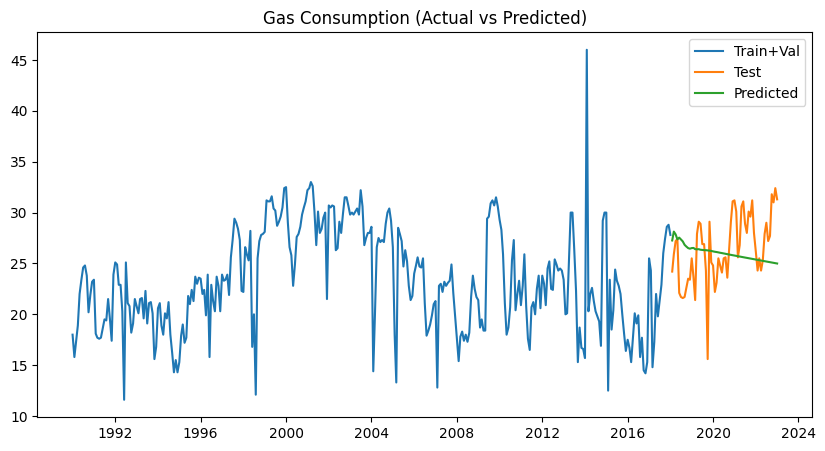

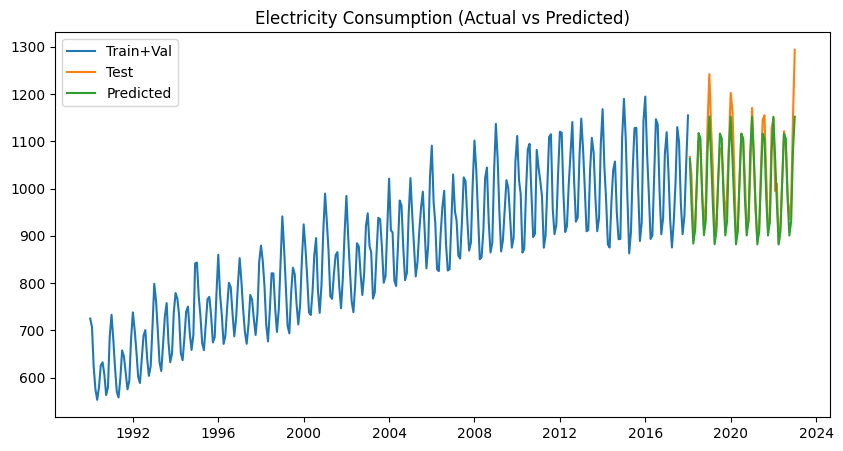

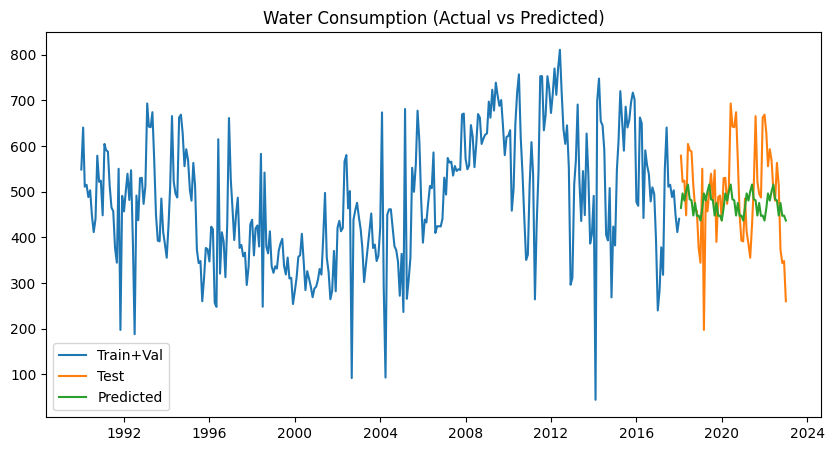

In [26]:
# Function to plot actual vs predicted values along with training+validation data
def plot_forecast(actual, pred, train_val, title):
    plt.figure(figsize=(10,5))
    plt.plot(train_val.index, train_val, label="Train+Val")
    plt.plot(actual.index, actual, label="Test")
    plt.plot(pred.index, pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

# Gas
plot_forecast(gas_test, gas_pred, gas_train_val, "Gas Consumption (Actual vs Predicted)")

# Electricity
plot_forecast(elec_test, elec_pred, elec_train_val, "Electricity Consumption (Actual vs Predicted)")

# Water
plot_forecast(water_test, water_pred, water_train_val, "Water Consumption (Actual vs Predicted)")

## Evaluation Result

| Series | MAPE (Test) | RMSE (Test) |
|--------|-------------|-------------|
| Gas | 0.1172 | 3.7255 |
| Electricity | 0.0280 | 41.5967 |
| Water | 0.1786 | 104.2275 |

### Gas Consumption

#### Observations (Actual vs Predicted)

- **Actual** gas consumption shows an **upward trend** from 2018 to 2023.

- **Predicted** values are **relatively flat and downward** and **fail to capture** the upward trend.

The model consistently **underestimates** the later period.

#### Interpretation

- The model **cannot fully capture** the **increasing trend**.

- Although MAPE is moderate, the forecast plot indicates the model is not sufficient for this series.

Improvement suggestions: add exogenous variables, use a more complex model, or handle outliers/trend better.

### Electricity Consumption

#### Observations (Actual vs Predicted)

- **Actual** electricity consumption shows **strong seasonality** with repeated yearly peaks and troughs.

- **Predicted** values **follow the seasonal pattern** closely, with **minor deviations** at peak points.

#### Interpretation

- The tuned SARIMA model **captures trend and seasonality well**.

Electricity series is highly predictable, leading to the best forecasting accuracy among the three.

### Water Consumption

#### Observations (Actual vs Predicted)

- **Actual** water consumption **fluctuates widely** with sharp peaks and drops.

- **Predicted** values are **smoother** and **fail to capture sudden spikes**.

The model **underestimates** major peaks.

#### Interpretation

- Water is highly volatile and noisy, so the model struggles to forecast sudden changes.

Tuned ETS improves over baseline but still has limited accuracy due to inherent variability.

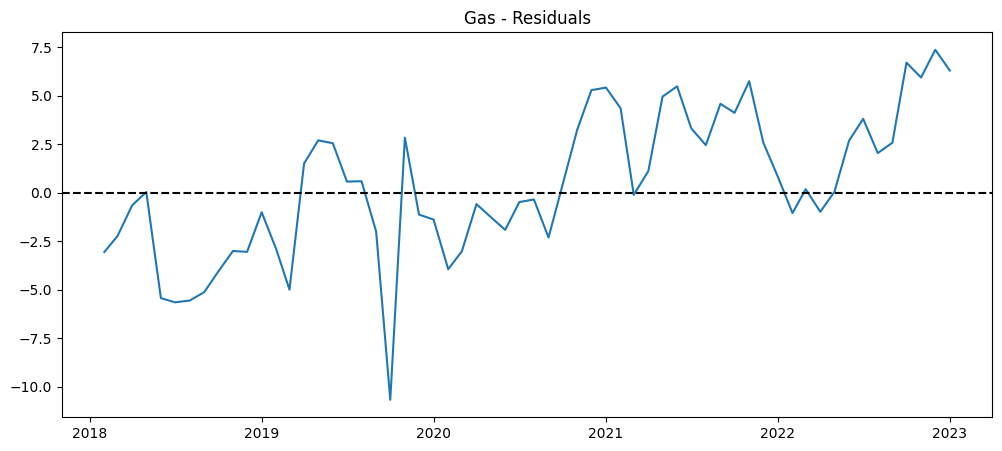

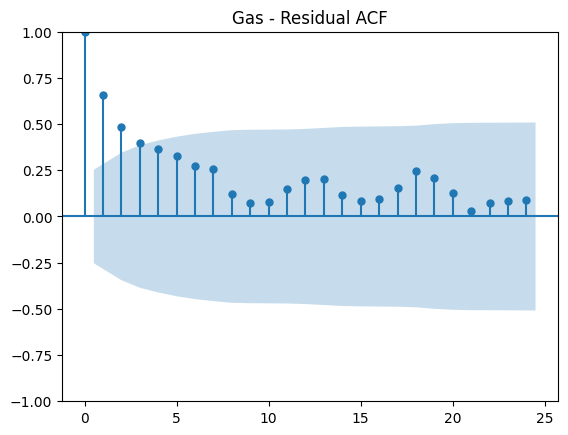

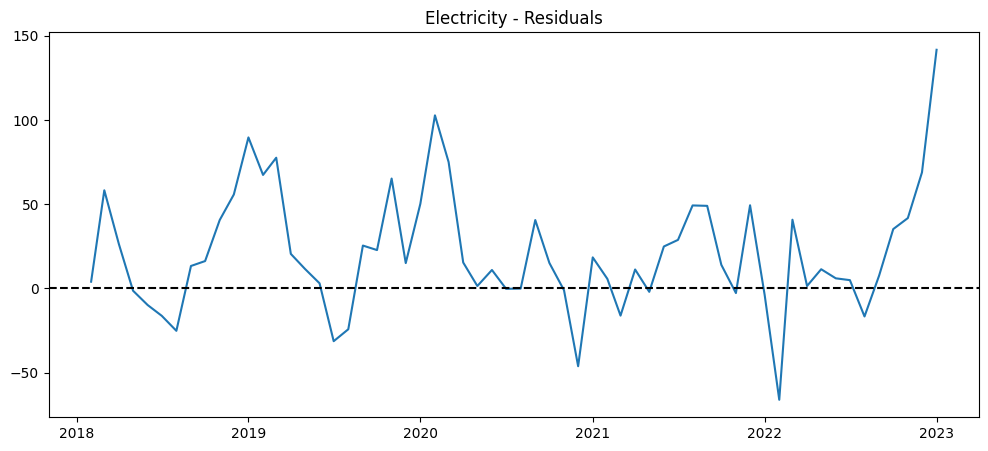

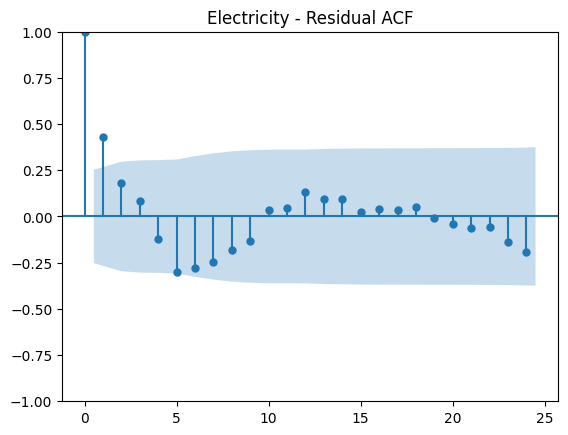

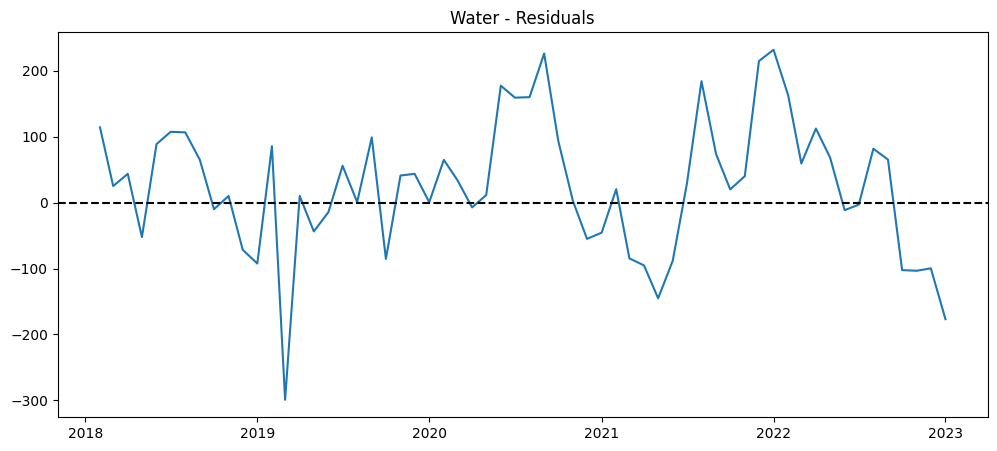

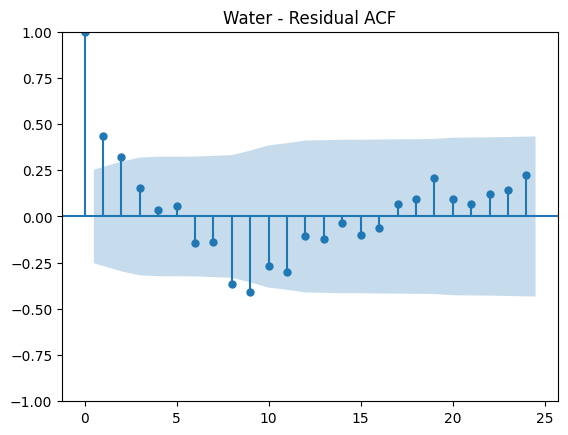

In [27]:
import statsmodels.api as sm

# Function to plot residuals and their autocorrelation
def plot_residuals(actual, pred, title):
    residual = actual - pred

    # Plot residuals over time
    plt.figure(figsize=(12,5))
    plt.plot(residual)
    plt.title(title + " - Residuals")
    plt.axhline(0, linestyle='--', color='black')
    plt.show()

    # Plot autocorrelation function (ACF) to check for patterns in residuals
    fig = sm.graphics.tsa.plot_acf(residual, lags=24)
    plt.title(title + " - Residual ACF")
    plt.show()

# Gas residuals
plot_residuals(gas_test, gas_pred, "Gas")

# Electricity residuals
plot_residuals(elec_test, elec_pred, "Electricity")

# Water residuals
plot_residuals(water_test, water_pred, "Water")

### Residual Analysis (Model Fit)
#### Gas
- Residuals fluctuate **around zero** but show a **clear positive bias** after 2020.

- Residual ACF shows significant autocorrelation at lag 1, indicating remaining time dependence.

Conclusion: The model has not fully captured the underlying structure and needs improvement.

#### Electricity
- Residuals are **mostly centered around zero** with moderate fluctuations.

- ACF shows minor significant lags, suggesting slight autocorrelation.

Conclusion: The model fits well overall, but slight refinement could improve peak accuracy.

#### Water
- Residuals show **large swings and extreme outliers**.

- ACF reveals strong autocorrelation, indicating the model fails to explain the series structure.

Conclusion: The model does not fit well; a more complex model or additional preprocessing is needed.

---
Overall Summary

- **Electricity forecasting performs best** due to strong seasonality and stable trend.

- Gas and water models show limitations because of trend changes, spikes, and high volatility.

## 7. Forecasting (Next 60 Months)

In this step, the best-performing model for each time series is used to forecast the next 60 months (5 years).

The objectives are:
- Generate future forecasts based on the tuned model
- Visualize forecasts with confidence intervals
- Interpret the forecasted trend and uncertainty

Forecasting future values allows us to evaluate how well the model generalizes beyond the observed data and provides insights for long-term planning.


In [126]:
# Combine all data (train + validation + test) for final model fitting
full_data = pd.concat([train, val, test])

gas_model_final = SARIMAX(
    full_data['Gas Consumption (tons)'],
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

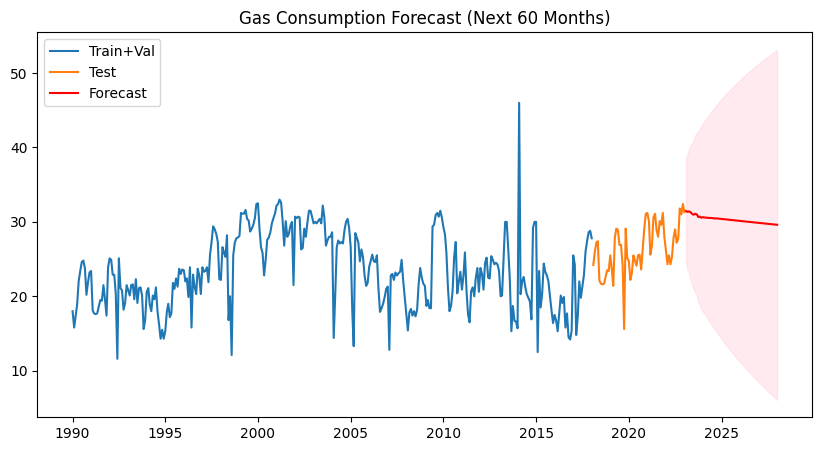

In [127]:
# Set forecast horizon to 60 months
n_steps = 60

# Generate forecast using the final SARIMA model
gas_forecast = gas_model_final.get_forecast(steps=n_steps)
gas_forecast_pred = gas_forecast.predicted_mean
gas_forecast_ci = gas_forecast.conf_int()

# Plot actual and forecasted Gas Consumption
plt.figure(figsize=(10,5))
plt.plot(train_val.index, train_val['Gas Consumption (tons)'], label="Train+Val")
plt.plot(test.index, test['Gas Consumption (tons)'], label="Test")
plt.plot(gas_forecast_pred.index, gas_forecast_pred, label="Forecast", color="red")
plt.fill_between(gas_forecast_ci.index,
                 gas_forecast_ci.iloc[:, 0],
                 gas_forecast_ci.iloc[:, 1],
                 color="pink", alpha=0.3)
plt.title("Gas Consumption Forecast (Next 60 Months)")
plt.legend()
plt.show()

In [128]:
elec_model_final = SARIMAX(
    full_data['Electricity Consumption (MWh)'],
    order=(1,0,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

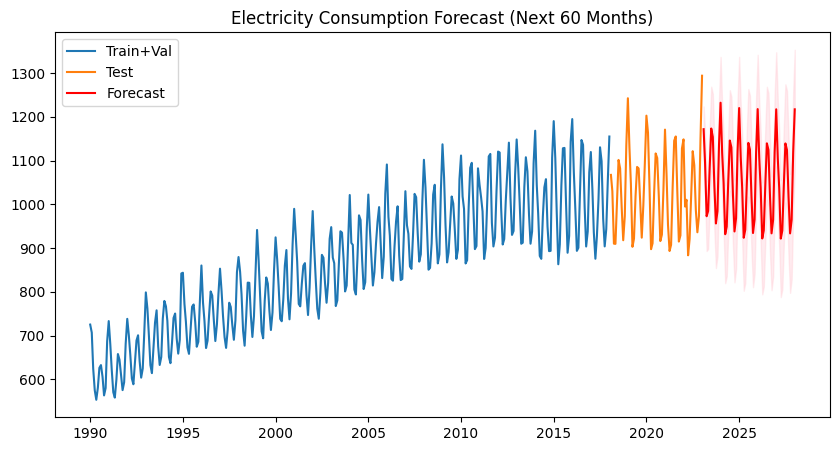

In [129]:
# Generate forecast using the final SARIMA model
elec_forecast = elec_model_final.get_forecast(steps=n_steps)
elec_forecast_pred = elec_forecast.predicted_mean
elec_forecast_ci = elec_forecast.conf_int()

# Plot actual and forecasted Electricity Consumption
plt.figure(figsize=(10,5))
plt.plot(train_val.index, train_val['Electricity Consumption (MWh)'], label="Train+Val")
plt.plot(test.index, test['Electricity Consumption (MWh)'], label="Test")
plt.plot(elec_forecast_pred.index, elec_forecast_pred, label="Forecast", color="red")
plt.fill_between(elec_forecast_ci.index,
                 elec_forecast_ci.iloc[:, 0],
                 elec_forecast_ci.iloc[:, 1],
                 color="pink", alpha=0.3)
plt.title("Electricity Consumption Forecast (Next 60 Months)")
plt.legend()
plt.show()

In [130]:
water_model_final = ExponentialSmoothing(
    full_data['Water Consumption (tons)'],
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    damped_trend=True
).fit(optimized=True)

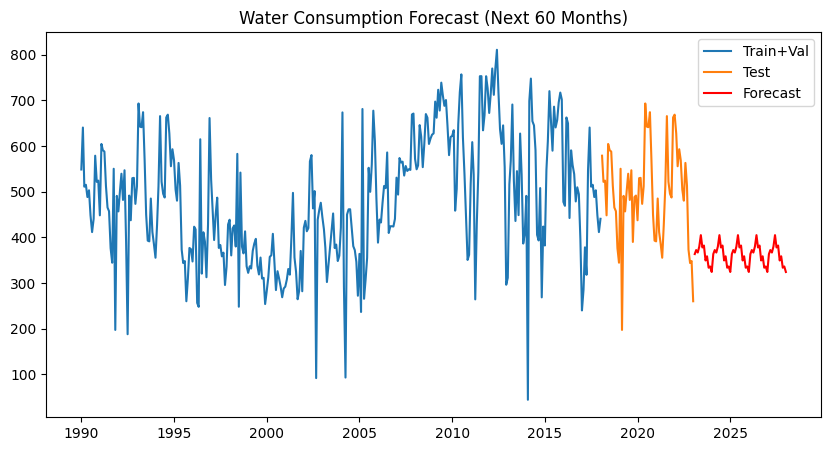

In [131]:
# Forecast next 60 months using the final ETS model for Water Consumption
water_forecast = water_model_final.forecast(n_steps)

# Create datetime index for the forecast starting after the last test data point
water_forecast.index = pd.date_range(start=test.index[-1],
                                     periods=n_steps+1,
                                     freq='MS')[1:]

# Plot actual and forecasted Water Consumption
plt.figure(figsize=(10,5))
plt.plot(train_val.index, train_val['Water Consumption (tons)'], label="Train+Val")
plt.plot(test.index, test['Water Consumption (tons)'], label="Test")
plt.plot(water_forecast.index, water_forecast, label="Forecast", color="red")
plt.title("Water Consumption Forecast (Next 60 Months)")
plt.legend()
plt.show()

## Interpretation of Forecast Results

### Gas Consumption Forecast (Next 60 Months)

- The 60-month forecast suggests that gas consumption is expected to **remain largely stable**, with a **slight downward or flat trend** in the predicted mean. The **confidence interval gradually widens** over the forecast horizon, reflecting **increasing uncertainty** as predictions extend further into the future.

Overall, the results indicate that gas consumption is unlikely to experience significant growth in the near future but may continue to fluctuate around its historical average.

---

### Electricity Consumption Forecast (Next 60 Months)

- The forecast for the next 60 months **continues upward trend**, accompanied by **pronounced seasonal variations**. The predicted peaks and troughs **align well** with historical seasonal behavior. The **confidence intervals expand over time**, particularly during peak periods, suggesting **increasing uncertainty** during periods of high demand.

These results imply that electricity demand is expected to grow steadily in the future, driven by long-term structural factors while maintaining strong seasonal characteristics.

---

### Water Consumption Forecast (Next 60 Months)

- The forecasted water consumption over the next 60 months appears **relatively stable**, with **smaller fluctuations** compared to historical observations. The model tends to revert predictions toward the long-term mean, suggesting **limited ability to capture** abrupt or irregular changes.

In summary, water consumption is expected to remain stable in the medium term; however, due to the high variability in historical data, long-term predictions should be interpreted with caution.

---

### Overall Conclusion

- Gas consumption is projected to remain relatively stable with minor fluctuations.
- Electricity consumption is expected to continue increasing and exhibits strong seasonal patterns.
- Water consumption forecasts indicate stability but with higher historical uncertainty.
- For all three forecasts, the widening confidence intervals highlight increasing uncertainty over longer forecast horizons.

## 8. Model Improvement

---

### Objective

The purpose of this step is to evaluate whether model performance can be improved through model tuning and better handling of time series characteristics, such as seasonality and noise. Model performance is assessed using error metrics (MAPE and RMSE) on the test dataset.

---

### Baseline Model Performance

Initially, baseline forecasting models were fitted for gas, electricity, and water consumption using default or minimally tuned parameters.

- **Gas consumption** showed relatively stable behavior, and the baseline model was able to capture the general level but with moderate forecasting error.

- **Electricity consumption** exhibited a strong trend and seasonality, and even the baseline model performed reasonably well.

- **Water consumption** displayed high volatility and irregular fluctuations, resulting in comparatively weaker baseline performance.

The baseline results suggest that model performance varies significantly depending on the underlying data characteristics.

---

### Model Tuning and Seasonality Consideration

To improve forecasting accuracy, hyperparameter tuning was applied to the models. This included adjusting parameters related to:

- Trend components  
- Seasonal components (where applicable)  
- Error structures  

For gas consumption, tuning resulted in slight improvements, as the series is relatively stable with weaker seasonal effects.

For electricity consumption, explicitly modeling seasonality led to a notable reduction in both MAPE and RMSE, indicating a better fit to the data. This confirms that capturing seasonal patterns is crucial for time series with strong periodic behavior.

For water consumption, improvements were limited. Although tuning reduced errors marginally, the high level of randomness and noise in the data constrained the model’s ability to achieve substantial gains.

---

### Comparison of Results (Before vs After Tuning)

Overall, the tuned models demonstrated:

- Lower **MAPE** and **RMSE** compared to the baseline models  
- More realistic forecasts that align better with historical trends and seasonal behavior  
- Improved generalization performance on test data, especially for electricity consumption  

This comparison highlights that hyperparameter tuning improves performance by optimizing the model structure, rather than by changing the underlying data itself.

---

### Discussion on Outliers and Noise

Outliers and noise were not explicitly removed during preprocessing in this analysis. This decision was made to preserve the original data structure and avoid subjective assumptions about what constitutes an abnormal observation.

However, for series such as water consumption, the presence of high noise and potential outliers likely contributed to higher forecast errors and wider confidence intervals. Removing or smoothing extreme values could potentially improve model stability, but it may also risk eliminating genuine consumption patterns.

As a future enhancement, a parallel experiment could be conducted where outliers and noise are handled during preprocessing, and the resulting forecasts are compared against the current approach.

---

### Conclusion

Model improvement was achieved primarily through appropriate tuning and seasonality modeling, particularly for electricity consumption. While tuning led to measurable error reductions, the effectiveness of improvements depends strongly on the nature of the data. Highly volatile series remain challenging to forecast accurately, even with optimized models.